In [1]:
import pandas as pd

In [ ]:
chol1 = pd.read_spss("voorbeeld7_1.sav")

chol1.head()

,id,chol,leeftijd,bmi,actief,roken,sekse,alcohol
0,1.0,7.9,66.0,27.41,inactief,niet roker,man,niet drinkers
1,2.0,7.5,83.0,26.85,inactief,niet roker,man,zware drinkers
2,3.0,7.6,84.0,27.24,inactief,niet roker,man,zware drinkers
3,4.0,6.0,65.0,27.50,inactief,niet roker,man,zware drinkers
4,5.0,6.2,56.0,27.78,inactief,niet roker,man,niet drinkers


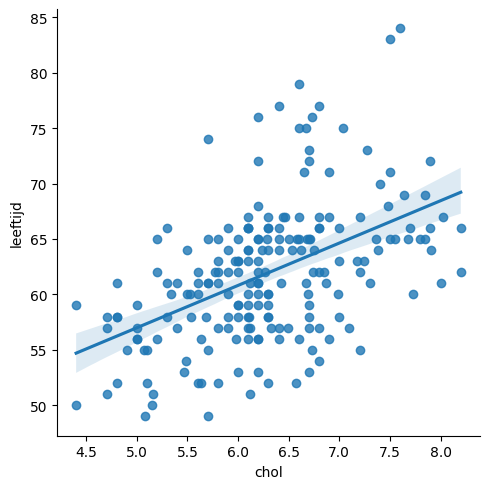

In [3]:
from seaborn import lmplot

lmplot(chol1, x="chol", y="leeftijd", fit_reg=True)

In [4]:
from statsmodels.formula.api import ols

fit1 = ols("chol ~ leeftijd", data=chol1).fit()

fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   chol   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     61.19
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.04e-13
Time:                        14:27:03   Log-Likelihood:                -212.39
No. Observations:                 200   AIC:                             428.8
Df Residuals:                     198   BIC:                             435.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4584      0.492      5.002      0.000       1.489       3.428
leeftijd       0.0618      0.008      7.822      0.000       0.046       0.077
==============================================================================
Omnibus:                        3.098   Durbin-Watson:                   1.036
Prob(Omnibus):                  0.212   Jarque-Bera (JB):                3.162
Skew:                           0.286   Prob(JB):                        0.206
Kurtosis:                       2.770   Cond. No.                         615.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
fit2 = ols("chol ~ leeftijd + bmi + sekse + alcohol", data=chol1).fit()

fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   chol   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     31.63
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.72e-23
Time:                        14:30:31   Log-Likelihood:                -179.70
No. Observations:                 200   AIC:                             371.4
Df Residuals:                     194   BIC:                             391.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.0299      0.751     -1.371      0.172      -2.512       0.452
sekse[T.vrouw]               -0.1961      0.259     -0.756      0.451      -0.708       0.316
alcohol[T.niet drinkers]      0.7280      0.270      2.701      0.008       0.196       1.260
alcohol[T.zware drinkers]     0.8333      0.153      5.457      0.000       0.532       1.135
leeftijd                      0.0344      0.008      4.289      0.000       0.019       0.050
bmi                           0.1721      0.020      8.415      0.000       0.132       0.212
==============================================================================
Omnibus:                        3.760   Durbin-Watson:                   1.055
Prob(Omnibus):                  0.153   Jarque-Bera (JB):                3.539
Skew:                           0.325   Prob(JB):                        0.170
Kurtosis:                       3.058   Cond. No.                     1.27e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.27e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Looking at the results, we see that the p value for `alcohol[T.niet drinkers]`, `alcohol[T.zware drinkers]`, `leeftijd`, and `bmi` are all less than 0.05, so these are all statistically significant predictors of cholesterol

<Axes: xlabel='fit2_residuals', ylabel='Count'>

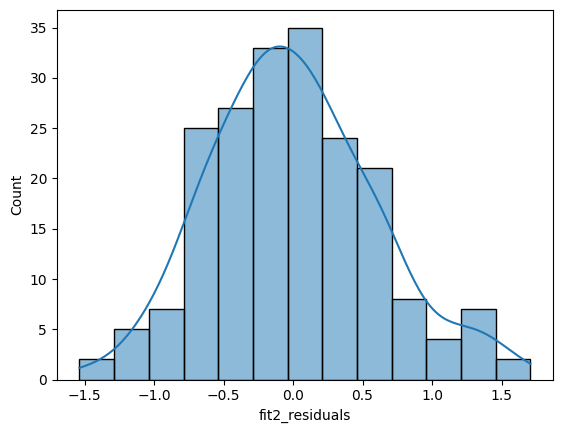

In [6]:
chol1["fit2_residuals"] = fit2.resid

from seaborn import histplot

histplot(chol1, x="fit2_residuals", kde=True)